# CNLOH profiles
## Results from ASCAT, sarek pipeline

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pybedtools

/home/msanchezg/miniconda3/envs/rhabdoids/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
sjd_dict = json.load(open('sample_ids/sample_sjd_ids.json','rb'))
tumors_dict = {'tumor1':'t1','tumor2':'t2'}

target_dict = json.load(open('sample_ids/sample_target_ids.json','rb'))
target_dict = {pt:target_dict[pt] for pt in target_dict.keys() if 'normal' in target_dict[pt].keys()}

stjude_dict = json.load(open('sample_ids/sample_stjude_ids.json','rb'))

pmc_dict = json.load(open('sample_ids/sample_pmc_ids.json','rb'))

samples_dict = sjd_dict | target_dict | stjude_dict | pmc_dict
pts = samples_dict.keys()

In [3]:
samples_final_ids_dict = json.load(open("sample_ids/sample_ids_final.json", "rb"))

In [4]:
purity_sjd_dict = json.load(open('purities/purities_sjd.json','rb'))
purity_target_dict = json.load(open('purities/purities_target.json','rb'))
purity_stjude_dict = json.load(open('purities/purities_stjude.json','rb'))
purity_pmc_dict = json.load(open('purities/purities_pmc_case.json','rb'))
purity_dict = purity_sjd_dict | purity_target_dict | purity_stjude_dict | purity_pmc_dict

In [5]:
smarcb1_df = pd.read_csv('variant_calling/Summary_SMARCB1_alterations.tsv',sep='\t', skiprows=1)
smarcb1_df = smarcb1_df[smarcb1_df['Excluded_samples'].isnull()]
smarcb1_df = smarcb1_df[smarcb1_df['SYMBOL']=='SMARCB1']
pts_with_22_cnloh = smarcb1_df['PATIENT'][smarcb1_df['CNLOH']==True].unique().tolist()
print(len(pts_with_22_cnloh))
pts_with_22_cnloh

35


['pt4',
 'pt6',
 'pt7',
 'pt8',
 'PADWRZ',
 'PAEHIP',
 'PAJLWM',
 'PAJMRB',
 'PAJNER',
 'PAJNFP',
 'PAJNFZ',
 'PARECB',
 'PAREWI',
 'PARGRN',
 'PARTKH',
 'PARUGK',
 'PASCDH',
 'PASWZZ',
 'PASXNA',
 'PASYNF',
 'PASZYE',
 'PATENH',
 'PATXEE',
 'PAUDPV',
 'PAUFVP',
 'PAUNPA',
 'PAVCKS',
 'PAVYKD',
 'PAWFWK',
 'SJ030997',
 'SJ031235',
 'SJ031948',
 'SJ032346',
 'SJ032417',
 'PMC01']

In [6]:
smarcb1_df = pd.read_csv('variant_calling/Summary_SMARCB1_alterations.tsv',sep='\t', skiprows=1)
smarcb1_df = smarcb1_df[smarcb1_df['Excluded_samples'].isnull()]
smarcb1_df = smarcb1_df[smarcb1_df['SYMBOL']=='SMARCA4']
pts_with_19_cnloh = smarcb1_df['PATIENT'][smarcb1_df['CNLOH']==True].unique().tolist()
print(len(pts_with_19_cnloh))
pts_with_19_cnloh

2


['pt15', 'PARIRN']

In [7]:
clinical_df = pd.read_csv('clinical_data/Clinical_Data_SJD_TARGET_StJude_PMC.tsv',sep='\t')
clinical_df['year'] = clinical_df['AGE_DIAGNOSIS'].astype(int)
clinical_df['month'] = clinical_df.apply(lambda row: int((row['AGE_DIAGNOSIS']-row['year'])*12),axis=1)
clinical_df['day'] = clinical_df.apply(lambda row: int((((row['AGE_DIAGNOSIS']-row['year'])*12)-row['month'])*30),axis=1)
age_dict = {}
for pt,y,m,d in zip(clinical_df['PATIENT'],clinical_df['year'],clinical_df['month'],clinical_df['day']):
    age_dict[pt] = {'year':y,
                    'month':m,
                    'day':d}
age_dict

{'pt18': {'year': 0, 'month': 0, 'day': 3},
 'pt4': {'year': 0, 'month': 0, 'day': 7},
 'pt13': {'year': 0, 'month': 0, 'day': 21},
 'PAUDPV': {'year': 0, 'month': 1, 'day': 23},
 'SJ032417': {'year': 0, 'month': 2, 'day': 1},
 'PAJNER': {'year': 0, 'month': 2, 'day': 2},
 'PASWZZ': {'year': 0, 'month': 2, 'day': 3},
 'PAVYKD': {'year': 0, 'month': 2, 'day': 5},
 'PATXKA': {'year': 0, 'month': 3, 'day': 10},
 'PARECB': {'year': 0, 'month': 4, 'day': 16},
 'PASVDP': {'year': 0, 'month': 4, 'day': 19},
 'PAJMBW': {'year': 0, 'month': 4, 'day': 19},
 'PATDVL': {'year': 0, 'month': 4, 'day': 24},
 'PARGRN': {'year': 0, 'month': 4, 'day': 24},
 'SJ034089': {'year': 0, 'month': 5, 'day': 1},
 'PAVYDM': {'year': 0, 'month': 5, 'day': 16},
 'PASABD': {'year': 0, 'month': 5, 'day': 20},
 'PAEHIP': {'year': 0, 'month': 5, 'day': 22},
 'pt9': {'year': 0, 'month': 5, 'day': 22},
 'SJ030997': {'year': 0, 'month': 6, 'day': 0},
 'PASYNF': {'year': 0, 'month': 6, 'day': 22},
 'PARRCL': {'year': 0, 'm

In [8]:
def age_text (age_dict,pt):
    age_pt_dict = age_dict[pt]
    y = str(age_pt_dict['year'])
    m = str(age_pt_dict['month'])
    d = str(age_pt_dict['day'])
    if y == '0':
        if m == '0':
            if d == '1':
                age = d+' day'
            else:
                age = d+' days'
        elif m == '1':
            age = m+' month'
        else:
            age = m+' months'
    elif y == '1':
        if m == '0':
            age = y+' year'
        elif m == '1':
            age = y+' year '+m+' month'
        else:
            age = y+' year '+m+' months'
    else:
        if m == '0':
            age = y+' years'
        elif m == '1':
            age = y+' years '+m+' month'
        else:
            age = y+' years '+m+' months'   
    return age
for pt in pts_with_22_cnloh:
    print(pt)
    print(age_dict[pt])
    print(age_text(age_dict,pt))

pt4
{'year': 0, 'month': 0, 'day': 7}
7 days
pt6
{'year': 1, 'month': 6, 'day': 7}
1 year 6 months
pt7
{'year': 1, 'month': 11, 'day': 22}
1 year 11 months
pt8
{'year': 3, 'month': 0, 'day': 0}
3 years
PADWRZ
{'year': 1, 'month': 0, 'day': 17}
1 year
PAEHIP
{'year': 0, 'month': 5, 'day': 22}
5 months
PAJLWM
{'year': 0, 'month': 9, 'day': 16}
9 months
PAJMRB
{'year': 1, 'month': 5, 'day': 23}
1 year 5 months
PAJNER
{'year': 0, 'month': 2, 'day': 2}
2 months
PAJNFP
{'year': 0, 'month': 11, 'day': 17}
11 months
PAJNFZ
{'year': 1, 'month': 7, 'day': 13}
1 year 7 months
PARECB
{'year': 0, 'month': 4, 'day': 16}
4 months
PAREWI
{'year': 0, 'month': 10, 'day': 2}
10 months
PARGRN
{'year': 0, 'month': 4, 'day': 24}
4 months
PARTKH
{'year': 0, 'month': 8, 'day': 21}
8 months
PARUGK
{'year': 0, 'month': 7, 'day': 6}
7 months
PASCDH
{'year': 0, 'month': 11, 'day': 19}
11 months
PASWZZ
{'year': 0, 'month': 2, 'day': 3}
2 months
PASXNA
{'year': 0, 'month': 9, 'day': 12}
9 months
PASYNF
{'year': 0, 

In [ ]:
def cnloh_plot (pt,t,cohort,chrom,age_dict,n):

    tumor_id = samples_dict[pt][t]
    normal_id = samples_dict[pt]['normal']
    sample_id = tumor_id +'_vs_'+normal_id

    df = pd.read_csv('variant_calling/'+cohort+'/sarek_results/'+cohort.split('_')[0]+'_variant_calling/ascat/'+sample_id+'/'+sample_id+'.segments.txt',sep='\t')
    chr_df = df[df['chr']==chrom]
    xmin = chr_df['startpos'].tolist()
    xmax = chr_df['endpos'].tolist()

    df = pd.read_csv('variant_calling/'+cohort+'/sarek_results/'+cohort.split('_')[0]+'_variant_calling/ascat/'+sample_id+'/'+sample_id+'.segments.txt',sep='\t')
    chr_df = df[df['chr']==chrom]
    # f, ax = plt.subplots(figsize=(8,3))
    ax = fig.add_subplot(gs[n])
    xmin = chr_df['startpos'].tolist()
    xmax = chr_df['endpos'].tolist()
    y = chr_df['nMajor'].tolist()
    y = [n+0.1 for n in y]
    ax.hlines(0.05, xmin[0]*0.6, xmax[-1], linewidth=1, linestyle='dashed')
    ax.hlines(1.05, xmin[0]*0.6, xmax[-1], linewidth=1, linestyle='dashed')
    ax.hlines(2.05, xmin[0]*0.6, xmax[-1], linewidth=1, linestyle='dashed')
    ax.hlines(y, xmin, xmax, linewidth=5, color='k')
    y = chr_df['nMinor'].tolist()
    ax.hlines(y, xmin, xmax, linewidth=5, color='r')
    if chrom == '22':
        ax.vlines(23786966,-1,3,color='cornflowerblue')
        ax.text(23786966,3.1,s='SMARCB1',ha='center')
        ax.set_xlim(0,xmax[-1]*1.04)
    else:
        ax.vlines(10961030,-1,3,color='cornflowerblue')
        ax.text(10961030,3.1,s='SMARCA4',ha='center')
        ax.set_xlim(-8000000,xmax[-1]*1.04)
    ax.set_ylim(-1,3)
    
    age = age_text(age_dict,pt)
        
    sample_final_id = samples_final_ids_dict[pt]
    ax.set_title(sample_final_id+'\n'+age+'\nChromosome '+str(chrom),size=18,pad=30)
    ax.text(x=0.01,y=0.8,s='2 copies',ha='left',va='center',transform = ax.transAxes)
    ax.text(x=0.01,y=0.55,s='1 copy',ha='left',va='center',transform = ax.transAxes)
    ax.text(x=0.01,y=0.3,s='no copies',ha='left',va='center',transform = ax.transAxes)
    ax.set_ylabel('Copy Number',size=16)
    ax.set_yticks([])
    ax.set_xticks([])

In [ ]:
def vaf_plot (pt,t,cohort,mafs,min_depth,chrom,n):

    tumor_id = samples_dict[pt][t]
    normal_id = samples_dict[pt]['normal']
    sample_id = tumor_id +'_vs_'+normal_id

    df = pd.read_csv('variant_calling/'+cohort+'/sarek_results/'+cohort.split('_')[0]+'_variant_calling/ascat/'+sample_id+'/'+sample_id+'.segments.txt',sep='\t')
    chr_df = df[df['chr']==chrom]
            
    xmin = chr_df['startpos'].tolist()
    xmax = chr_df['endpos'].tolist()

    path = 'mafs/'+mafs+'/'+pt+'/'+sample_id+'/filter_and_annot/'+sample_id+'_filt.maf.gz'

    if cohort == 'sjd_cohort':
        purity = purity_dict[pt+'_t'+t[-1]]
        sample_id = pt + '_'+t
    elif cohort == 'pmc_case':
        sample_id = samples_dict[pt][t]
        purity = purity_dict[sample_id]
        sample_id = pt + '_'+t
    else:
        purity = purity_dict[pt]
        sample_id = pt
    print(pt,t,purity)
    df = pd.read_csv(path,sep='\t')
    df['#CHROM'] = df['#CHROM'].astype(str)
    chr_df = df[(df['#CHROM']=='chr'+chrom)]
    chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)
    
    print(len(chr_df),'mutations in chr22')
    
    #filter clonal
    chr_df = chr_df[chr_df['clonal']==True]
    print(len(chr_df),'mutations after clonal filter')
    #filter gnomAF <0.001
    chr_df = chr_df[chr_df['gnomADg_AF']<0.001]
    print(len(chr_df),'mutations after gnomad <0.001 filter')
    #filter by depth
    chr_df = chr_df[chr_df['DP_tumor']>min_depth]
    print(len(chr_df),'mutations after DP >'+str(min_depth)+' filter')
    #select snvs
    chr_df = chr_df[chr_df['mut_type']=='snv']
    
    if len(chr_df) != 0:

        #filter out mutations from low mappability regions with pybedtools intersect with the mappable genome
        mapp_genome_df = pd.read_csv('mappable_genome/hg38_100bp.coverage.regions.filtered_blacklisted.gz',sep='\t')
        chr_mapp_genome_df = mapp_genome_df[mapp_genome_df['CHR']=='chr'+chrom]

        chr_copy_df = chr_df.copy()
        chr_copy_df['POS2'] = chr_df['POS'] + 1
        chr_copy_df = chr_copy_df[['#CHROM','POS','POS2','REF','ALT','FILTER']]
        mappgen_bt = pybedtools.BedTool.from_dataframe(chr_mapp_genome_df)
        snvs_bt = pybedtools.BedTool.from_dataframe(chr_copy_df)
        mappgen_and_snvs = snvs_bt.intersect(mappgen_bt)
        chr_mappgen_df = mappgen_and_snvs.to_dataframe()
        if len(chr_mappgen_df) == 0:
            chr_mappgen_df = pd.DataFrame(columns=['#CHROM','POS','REF','ALT','FILTER','nMajor','nMinor'])
        else:
            chr_mappgen_df = chr_mappgen_df.rename(columns={'chrom':'#CHROM','start':'POS','end':'POS2',
                                                                'name':'REF','score':'ALT','strand':'FILTER'})
            chr_mappgen_df = chr_mappgen_df.drop(columns=['POS2'])

        chr_df = pd.merge(chr_mappgen_df,chr_df,how='left')
        print(len(chr_copy_df), len(chr_df), 'before - after filtering for mappable genome')
        
    num_muts = str(len(chr_df))

    #f, ax = plt.subplots(figsize=(8,3))
    ax = fig.add_subplot(gs[n])
    ax.axhline(0.5,linestyle='-',color='blue',linewidth=35,alpha=0.2)
    ax.axhline(1,linestyle='-',color='orange',linewidth=35,alpha=0.3)
    ax.hlines(0.0, xmin[0]*0.6, xmax[-1], linewidth=1, linestyle='dashed')
    ax.hlines(0.5, xmin[0]*0.6, xmax[-1], linewidth=1, linestyle='dashed')
    ax.hlines(1.0, xmin[0]*0.6, xmax[-1], linewidth=1, linestyle='dashed')
    ax.plot(chr_df['POS'],chr_df['t_AF_corrected'],linewidth=0,marker='o',markersize=5)
    ax.set_ylim(-0.5,1.5)
    if chrom == '22':
        ax.vlines(23786966,-0.5,1.5,color='cornflowerblue')
        ax.set_xlim(0,xmax[-1]*1.04)
    else:
        ax.vlines(10961030,-1,3,color='cornflowerblue')
        ax.set_xlim(-8000000,xmax[-1]*1.04)
    ax.text(x=0.01,y=0.6,s='Heterozygous',ha='left',va='center',transform = ax.transAxes)
    ax.text(x=0.01,y=0.85,s='Homozygous',ha='left',va='center',transform = ax.transAxes)
    ax.set_ylabel('Variant Allele\nFrequency',size=16)
    ax.set_xlabel('Genomic positon',size=16)#,labelpad=70)
    ax.set_xticks(range(0,xmax[-1],10000000))#,labels=[])
    ax.set_yticks([0,0.5,1])

In [23]:
pt='PADWRZ'
t = 'tumor1'
mafs = 'mafs_target'
cohort = 'target_cohort'
min_depth = 20
tumor_id = samples_dict[pt][t]
normal_id = samples_dict[pt]['normal']
sample_id = tumor_id +'_vs_'+normal_id
chrom = '22'
path = 'mafs/'+mafs+'/'+pt+'/'+sample_id+'/filter_and_annot/'+sample_id+'_filt.maf.gz'
purity = purity_dict[pt]
sample_id = pt
print(pt,t,purity)
df = pd.read_csv(path,sep='\t')
df['#CHROM'] = df['#CHROM'].astype(str)
chr_df = df[(df['#CHROM']=='chr'+chrom)]
chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)
#filter clonal
chr_df = chr_df[chr_df['clonal']==True]
print(len(chr_df),'mutations after clonal filter')
#filter gnomAF <0.001
chr_df = chr_df[chr_df['gnomADg_AF']<0.001]
print(len(chr_df),'mutations after gnomad <0.001 filter')
#filter by depth
chr_df = chr_df[chr_df['DP_tumor']>min_depth]
print(len(chr_df),'mutations after DP >'+str(min_depth)+' filter')
#select snvs
# chr_df = chr_df[chr_df['mut_type']=='snv']
chr_df[['SYMBOL','POS','REF','ALT','Consequence','aa_change','t_AF','t_AF_corrected']]


PADWRZ tumor1 0.78
17 mutations after clonal filter
13 mutations after gnomad <0.001 filter
11 mutations after DP >20 filter


/tmp/ipykernel_913792/221346735.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


,SYMBOL,POS,REF,ALT,Consequence,aa_change,t_AF,t_AF_corrected
465,-,11800137,A,C,intergenic_variant,-,0.258,0.330769
467,CLTCL1,19280079,A,G,intron_variant,-,0.378,0.484615
468,KLHL22,20472375,G,A,intron_variant,-,0.393,0.503846
470,SMARCB1,23791833,-,GGAAGAGGCGCCACGCTTTCGGCAGCAGA,frameshift_variant,V57VEEAPRFRQQX,0.933,1.196154
471,SMARCB1,23806498,G,C,intron_variant,-,0.795,1.019231
475,-,31963403,C,A,non_coding_transcript_exon_variant,-,0.286,0.366667
476,-,35711091,A,T,intergenic_variant,-,0.289,0.370513
477,-,35711175,C,A,intergenic_variant,-,0.226,0.289744
479,TCF20,42162738,C,G,intron_variant,-,0.242,0.310256
480,CELSR1,46493143,G,T,intron_variant,-,0.400,0.512821


In [24]:

import matplotlib.gridspec as gridspec

pt15 tumor1 0.58
110 mutations in chr22
84 mutations after clonal filter
74 mutations after gnomad <0.001 filter
65 mutations after DP >80 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


60 52 before - after filtering for mappable genome


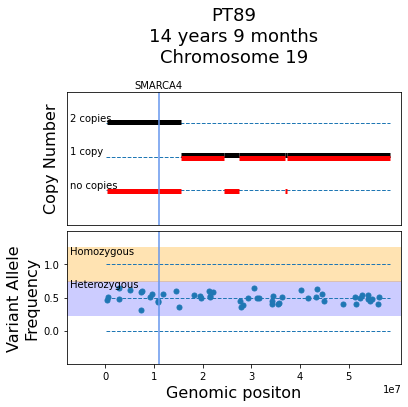

PARIRN tumor1 0.8
11 mutations in chr22
9 mutations after clonal filter
6 mutations after gnomad <0.001 filter
4 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


3 3 before - after filtering for mappable genome


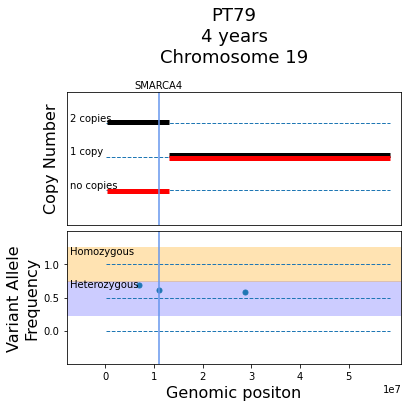

In [25]:
for pt in pts_with_19_cnloh:
    if pt.startswith('pt'):
        cohort = 'sjd_cohort'
        mafs = 'mafs_sjd'
        depth = 80
    elif pt.startswith('PMC'):
        cohort = 'pmc_case'
        mafs = 'mafs_pmc'
        depth = 20
    elif pt.startswith('PA'):
        cohort = 'target_cohort'
        mafs = 'mafs_target'
        depth=20
    else:
        cohort = 'stjude_cohort'
        mafs = 'mafs_stjude'
        depth=20
    for t in [t for t in samples_dict[pt].keys() if t not in ['normal','normal2','sex','clone1','clone2']]:
        fig = plt.figure(figsize=(6,5))
        gs = gridspec.GridSpec(2,1,hspace=0.05)
        cnloh_plot (pt,t,cohort,chrom='19',age_dict=age_dict,n=0)
        vaf_plot (pt,t,cohort,mafs,depth,chrom='19',n=1)
        sample_final_id = samples_final_ids_dict[pt]
        out='plots/cnloh_plots/'+sample_final_id+'_'+t+'_CNLOH_profile.svg'
        plt.savefig(out,dpi=300,bbox_inches='tight',format='svg')
        plt.show()


pt4 tumor1 0.9
38 mutations in chr22
7 mutations after clonal filter
2 mutations after gnomad <0.001 filter
1 mutations after DP >80 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


1 1 before - after filtering for mappable genome


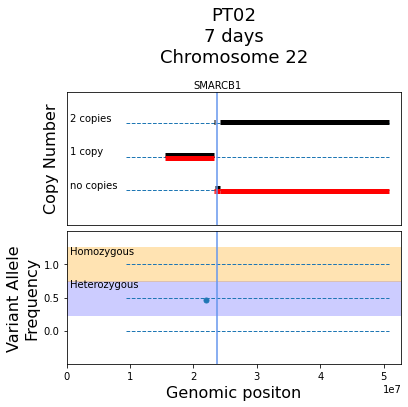

pt4 tumor2 0.9
17 mutations in chr22
12 mutations after clonal filter
1 mutations after gnomad <0.001 filter
1 mutations after DP >80 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


1 1 before - after filtering for mappable genome


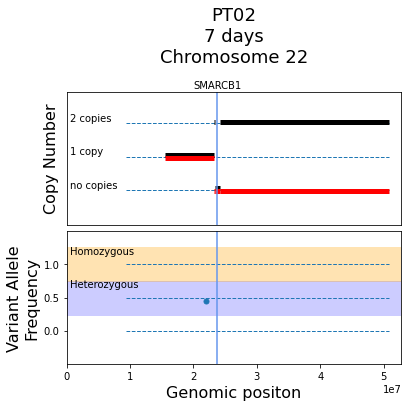

pt6 tumor1 0.93
22 mutations in chr22
21 mutations after clonal filter
13 mutations after gnomad <0.001 filter
13 mutations after DP >80 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


10 8 before - after filtering for mappable genome


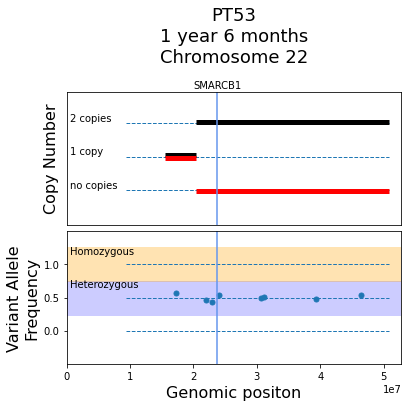

pt6 tumor2 0.84
41 mutations in chr22
20 mutations after clonal filter
13 mutations after gnomad <0.001 filter
13 mutations after DP >80 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


11 8 before - after filtering for mappable genome


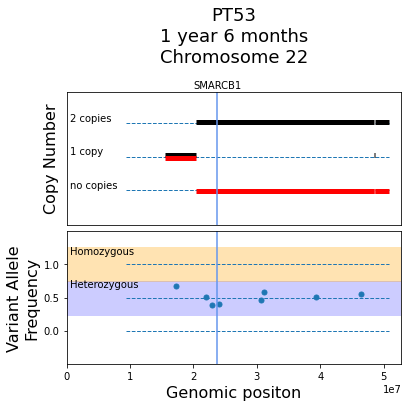

pt7 tumor1 0.37
63 mutations in chr22
63 mutations after clonal filter
50 mutations after gnomad <0.001 filter
49 mutations after DP >80 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


42 39 before - after filtering for mappable genome


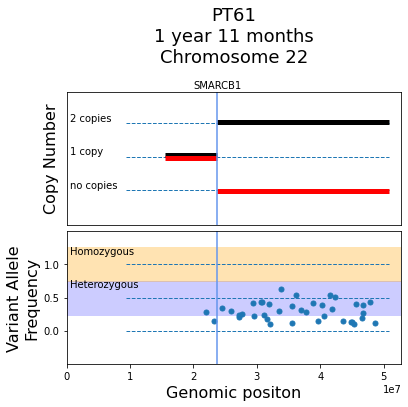

pt8 tumor1 0.67
25 mutations in chr22
12 mutations after clonal filter
6 mutations after gnomad <0.001 filter
6 mutations after DP >80 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


6 5 before - after filtering for mappable genome


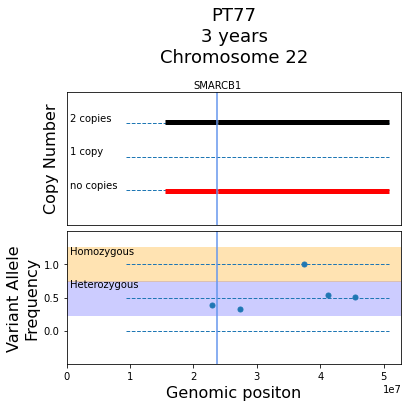

PADWRZ tumor1 0.78
18 mutations in chr22
17 mutations after clonal filter
13 mutations after gnomad <0.001 filter
11 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


10 9 before - after filtering for mappable genome


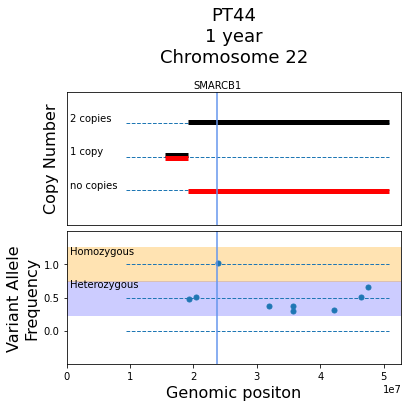

PAEHIP tumor1 0.88
7 mutations in chr22
5 mutations after clonal filter
2 mutations after gnomad <0.001 filter
2 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


2 2 before - after filtering for mappable genome


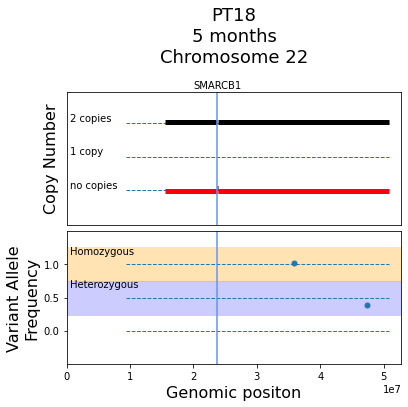

PAJLWM tumor1 0.92
6 mutations in chr22
4 mutations after clonal filter
3 mutations after gnomad <0.001 filter
3 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


2 2 before - after filtering for mappable genome


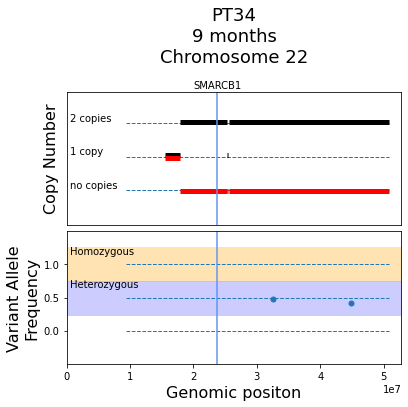

PAJMRB tumor1 0.66
7 mutations in chr22
7 mutations after clonal filter
4 mutations after gnomad <0.001 filter
4 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


4 3 before - after filtering for mappable genome


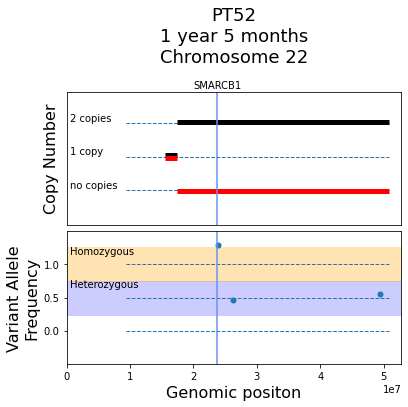

PAJNER tumor1 0.46
4 mutations in chr22
4 mutations after clonal filter
2 mutations after gnomad <0.001 filter
2 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


2 2 before - after filtering for mappable genome


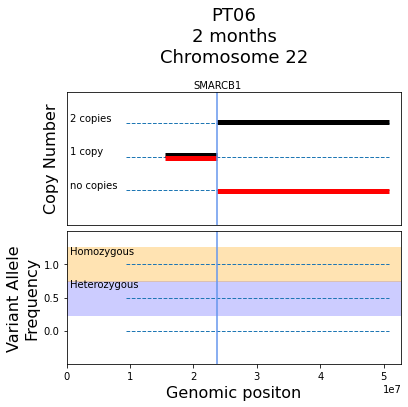

PAJNFP tumor1 0.74
12 mutations in chr22
7 mutations after clonal filter
3 mutations after gnomad <0.001 filter
3 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


3 3 before - after filtering for mappable genome


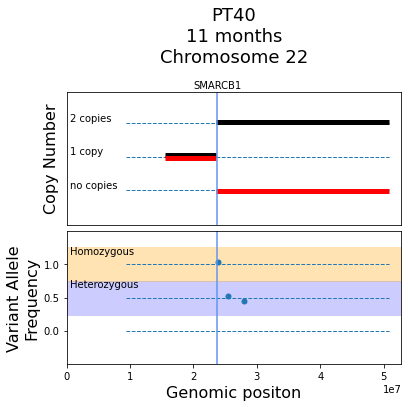

PAJNFZ tumor1 0.58
10 mutations in chr22
10 mutations after clonal filter
2 mutations after gnomad <0.001 filter
2 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


2 2 before - after filtering for mappable genome


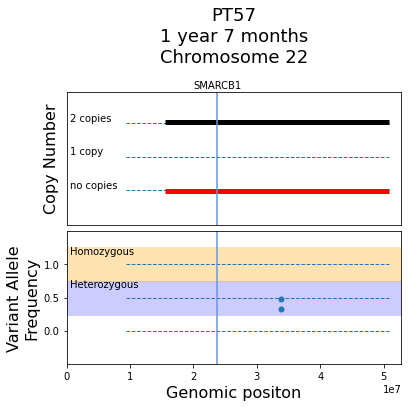

PARECB tumor1 0.84
5 mutations in chr22
5 mutations after clonal filter
1 mutations after gnomad <0.001 filter
1 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


1 0 before - after filtering for mappable genome


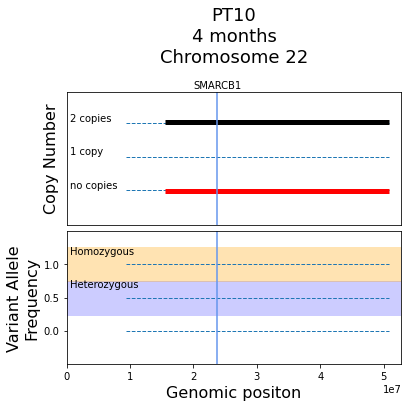

PAREWI tumor1 0.94
9 mutations in chr22
6 mutations after clonal filter
4 mutations after gnomad <0.001 filter
3 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


1 1 before - after filtering for mappable genome


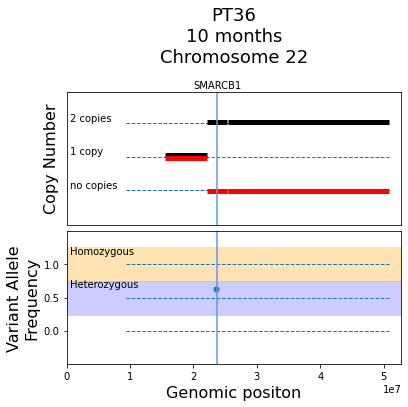

PARGRN tumor1 0.99
8 mutations in chr22
5 mutations after clonal filter
1 mutations after gnomad <0.001 filter
1 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


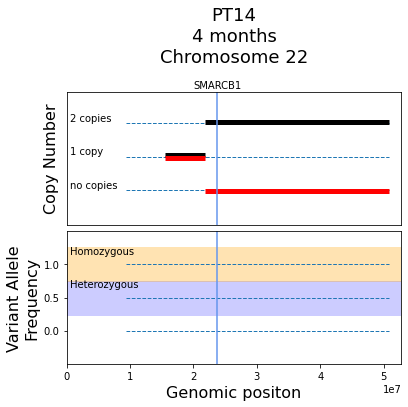

PARTKH tumor1 0.63
2 mutations in chr22
2 mutations after clonal filter
1 mutations after gnomad <0.001 filter
1 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


1 1 before - after filtering for mappable genome


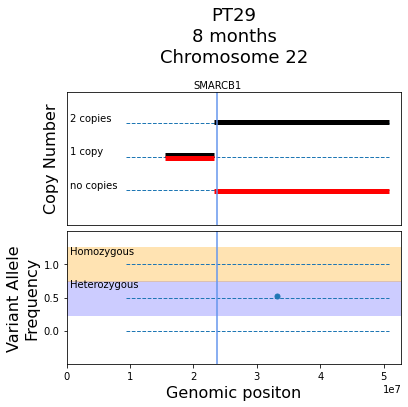

PARUGK tumor1 0.56
6 mutations in chr22
6 mutations after clonal filter
4 mutations after gnomad <0.001 filter
4 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


4 3 before - after filtering for mappable genome


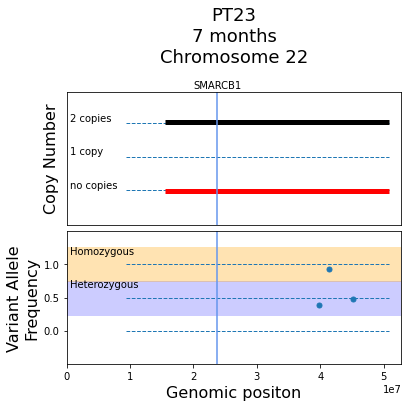

PASCDH tumor1 0.86
11 mutations in chr22
8 mutations after clonal filter
4 mutations after gnomad <0.001 filter
4 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


4 3 before - after filtering for mappable genome


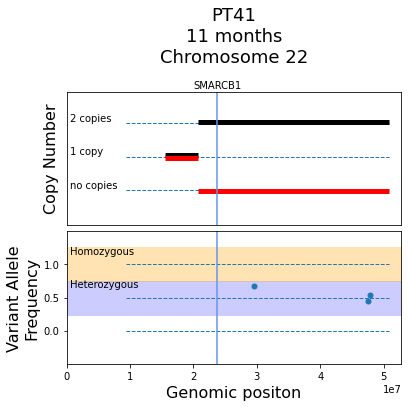

PASWZZ tumor1 0.86
9 mutations in chr22
8 mutations after clonal filter
3 mutations after gnomad <0.001 filter
3 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


3 3 before - after filtering for mappable genome


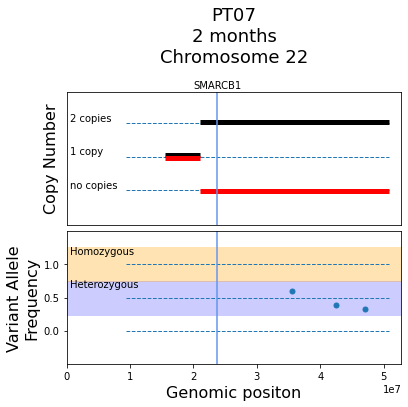

PASXNA tumor1 0.99
11 mutations in chr22
9 mutations after clonal filter
3 mutations after gnomad <0.001 filter
1 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


1 1 before - after filtering for mappable genome


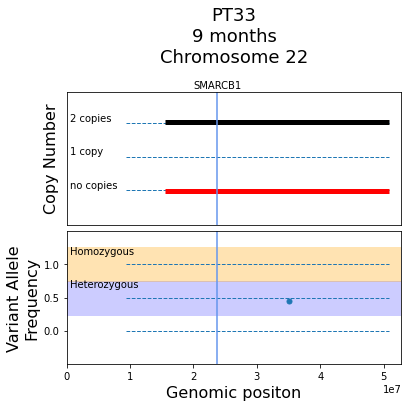

PASYNF tumor1 0.82
4 mutations in chr22
4 mutations after clonal filter
2 mutations after gnomad <0.001 filter
2 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


2 2 before - after filtering for mappable genome


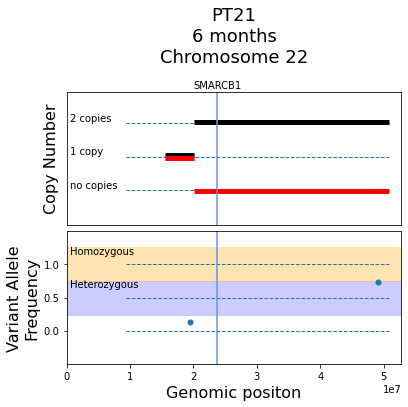

PASZYE tumor1 0.74
9 mutations in chr22
9 mutations after clonal filter
8 mutations after gnomad <0.001 filter
7 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


7 5 before - after filtering for mappable genome


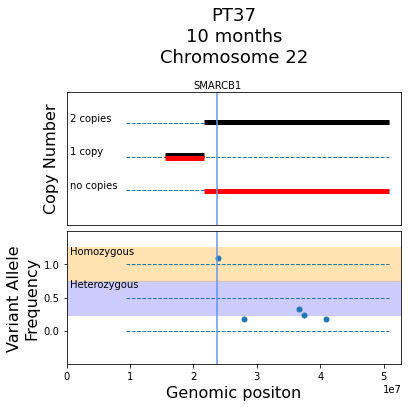

PATENH tumor1 0.74
15 mutations in chr22
13 mutations after clonal filter
13 mutations after gnomad <0.001 filter
13 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


10 9 before - after filtering for mappable genome


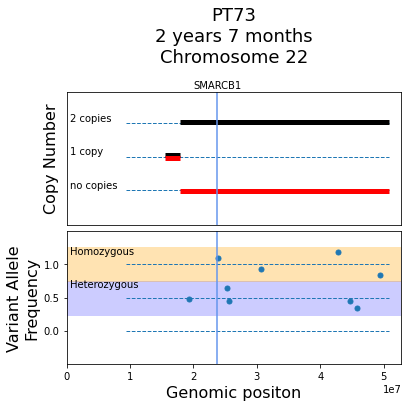

PATXEE tumor1 0.66
17 mutations in chr22
7 mutations after clonal filter
4 mutations after gnomad <0.001 filter
3 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


3 3 before - after filtering for mappable genome


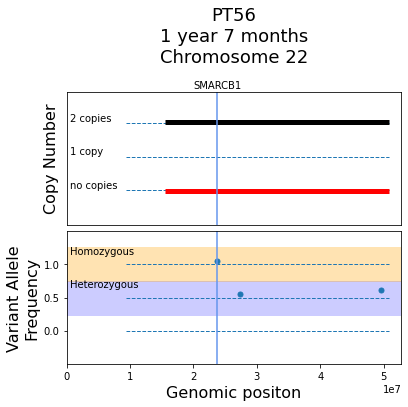

PAUDPV tumor1 0.88
5 mutations in chr22
5 mutations after clonal filter
1 mutations after gnomad <0.001 filter
1 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


1 1 before - after filtering for mappable genome


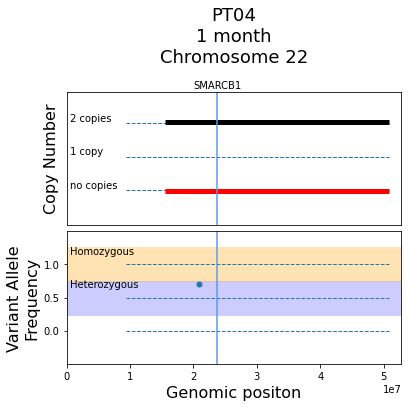

PAUFVP tumor1 0.86
15 mutations in chr22
15 mutations after clonal filter
9 mutations after gnomad <0.001 filter
9 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


7 5 before - after filtering for mappable genome


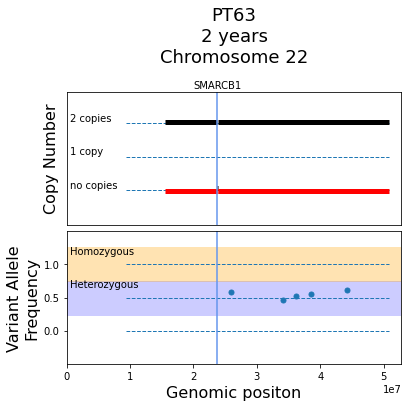

PAUNPA tumor1 0.78
13 mutations in chr22
13 mutations after clonal filter
9 mutations after gnomad <0.001 filter
9 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


8 7 before - after filtering for mappable genome


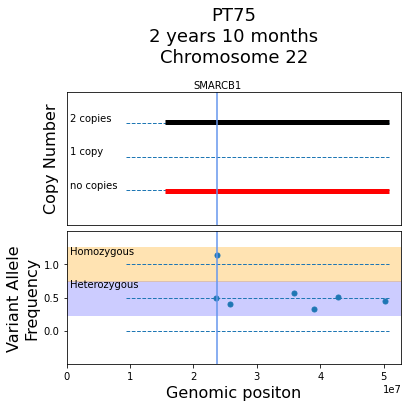

PAVCKS tumor1 0.84
14 mutations in chr22
13 mutations after clonal filter
12 mutations after gnomad <0.001 filter
10 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


8 5 before - after filtering for mappable genome


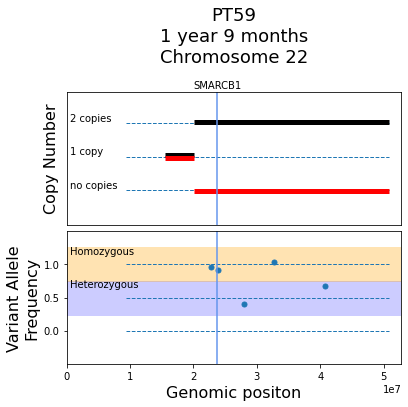

PAVYKD tumor1 0.82
4 mutations in chr22
4 mutations after clonal filter
4 mutations after gnomad <0.001 filter
4 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


4 4 before - after filtering for mappable genome


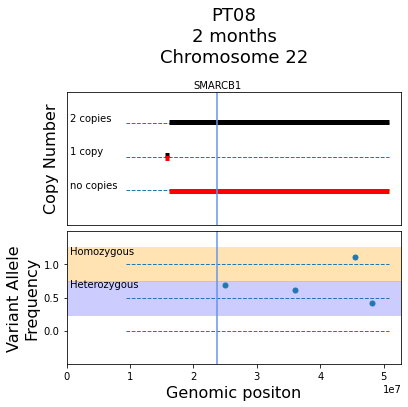

PAWFWK tumor1 0.98
19 mutations in chr22
17 mutations after clonal filter
11 mutations after gnomad <0.001 filter
10 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


10 8 before - after filtering for mappable genome


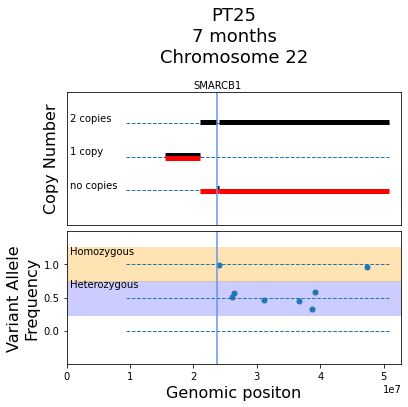

SJ030997 tumor1 0.86
13 mutations in chr22
9 mutations after clonal filter
5 mutations after gnomad <0.001 filter
5 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


5 3 before - after filtering for mappable genome


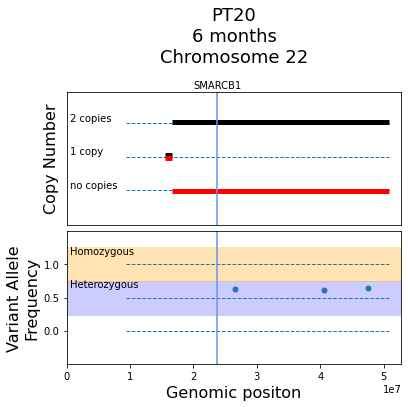

SJ031235 tumor1 0.8
1 mutations in chr22
1 mutations after clonal filter
1 mutations after gnomad <0.001 filter
1 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


1 1 before - after filtering for mappable genome


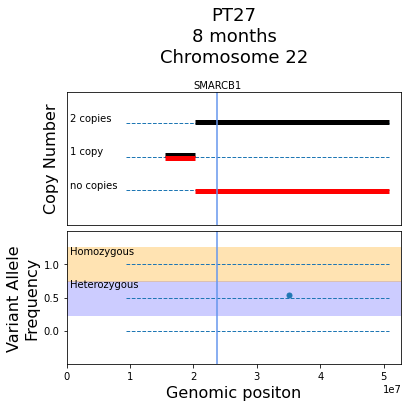

SJ031948 tumor1 0.91
86 mutations in chr22
71 mutations after clonal filter
66 mutations after gnomad <0.001 filter
66 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


55 49 before - after filtering for mappable genome


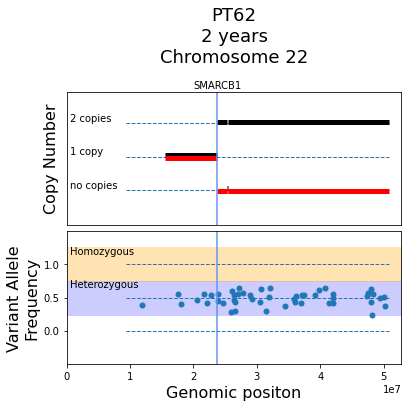

SJ032346 tumor1 0.87
18 mutations in chr22
18 mutations after clonal filter
12 mutations after gnomad <0.001 filter
12 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


11 9 before - after filtering for mappable genome


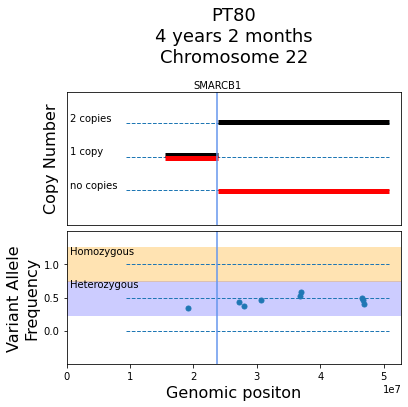

SJ032417 tumor1 0.84
14 mutations in chr22
6 mutations after clonal filter
2 mutations after gnomad <0.001 filter
2 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


1 1 before - after filtering for mappable genome


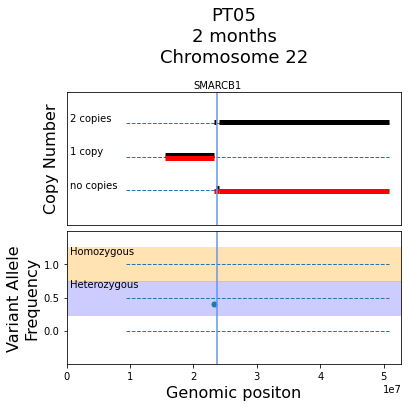

PMC01 tumor1 0.99
29 mutations in chr22
12 mutations after clonal filter
11 mutations after gnomad <0.001 filter
9 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


7 6 before - after filtering for mappable genome


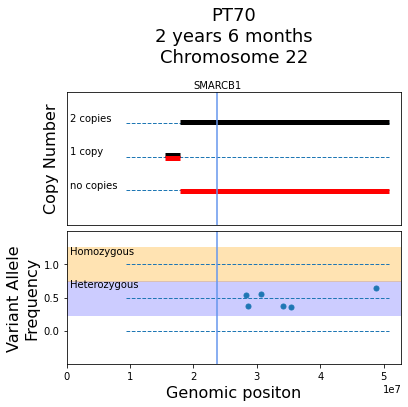

PMC01 tumor2 0.88
22 mutations in chr22
12 mutations after clonal filter
8 mutations after gnomad <0.001 filter
7 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


6 3 before - after filtering for mappable genome


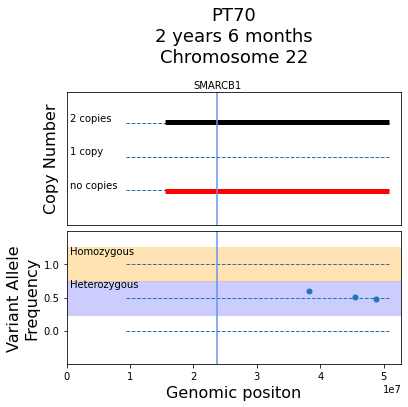

PMC01 tumor3 0.99
18 mutations in chr22
7 mutations after clonal filter
5 mutations after gnomad <0.001 filter
4 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


2 1 before - after filtering for mappable genome


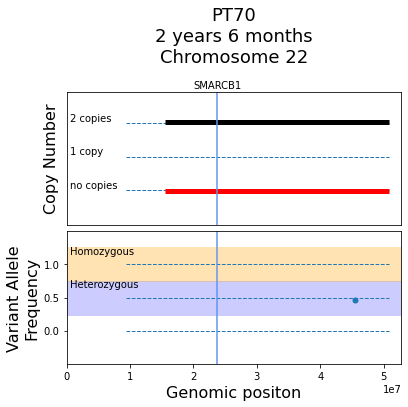

PMC01 tumor4 0.99
35 mutations in chr22
13 mutations after clonal filter
10 mutations after gnomad <0.001 filter
8 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


6 4 before - after filtering for mappable genome


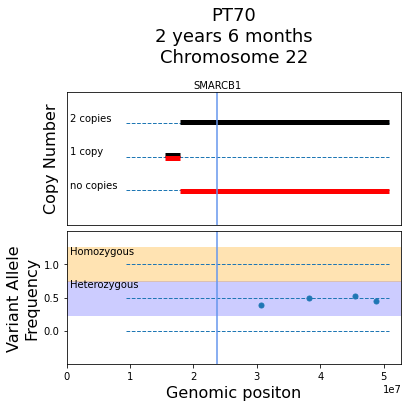

In [18]:
for pt in pts_with_22_cnloh:
    if pt.startswith('pt'):
        cohort = 'sjd_cohort'
        mafs = 'mafs_sjd'
        depth = 80
    elif pt.startswith('PMC'):
        cohort = 'pmc_case'
        mafs = 'mafs_pmc'
        depth = 20
    elif pt.startswith('PA'):
        cohort = 'target_cohort'
        mafs = 'mafs_target'
        depth=20
    else:
        cohort = 'stjude_cohort'
        mafs = 'mafs_stjude'
        depth=20
    for t in [t for t in samples_dict[pt].keys() if t not in ['normal','normal2','sex','clone1','clone2']]:
        fig = plt.figure(figsize=(6,5))
        gs = gridspec.GridSpec(2,1,hspace=0.05)
        cnloh_plot (pt,t,cohort,chrom='22',age_dict=age_dict,n=0)
        vaf_plot (pt,t,cohort,mafs,depth,chrom='22',n=1)
        sample_final_id = samples_final_ids_dict[pt]
        out='plots/cnloh_plots/'+sample_final_id+'_'+t+'_CNLOH_profile.svg'
        plt.savefig(out,dpi=300,bbox_inches='tight',format='svg')
        plt.show()
        

PAJNER tumor1 0.46
4 mutations in chr22
4 mutations after clonal filter
2 mutations after gnomad <0.001 filter
2 mutations after DP >20 filter


/tmp/ipykernel_913792/679396259.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


2 2 before - after filtering for mappable genome


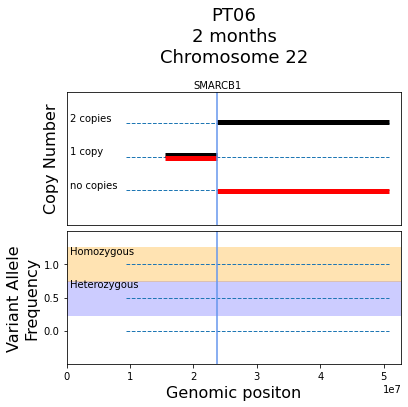

In [19]:
pt = 'PAJNER'


cohort = 'target_cohort'
mafs = 'mafs_target'
depth=20

t = 'tumor1'
fig = plt.figure(figsize=(6,5))
gs = gridspec.GridSpec(2,1,hspace=0.05)
cnloh_plot (pt,t,cohort,chrom='22',age_dict=age_dict,n=0)
vaf_plot (pt,t,cohort,mafs,depth,chrom='22',n=1)
sample_final_id = samples_final_ids_dict[pt]
plt.show()

In [ ]:
n=1
tumor_id = samples_dict[pt][t]
normal_id = samples_dict[pt]['normal']
sample_id = tumor_id +'_vs_'+normal_id

df = pd.read_csv('variant_calling/'+cohort+'/sarek_results/'+cohort.split('_')[0]+'_variant_calling/ascat/'+sample_id+'/'+sample_id+'.segments.txt',sep='\t')
chr_df = df[df['chr']==chrom]
        
xmin = chr_df['startpos'].tolist()
xmax = chr_df['endpos'].tolist()

path = 'mafs/'+mafs+'/'+pt+'/'+sample_id+'/filter_and_annot/'+sample_id+'_filt.maf.gz'

if cohort == 'sjd_cohort':
    purity = purity_dict[pt+'_t'+t[-1]]
    sample_id = pt + '_'+t
elif cohort == 'pmc_case':
    sample_id = samples_dict[pt][t]
    purity = purity_dict[sample_id]
    sample_id = pt + '_'+t
else:
    purity = purity_dict[pt]
    sample_id = pt
print(pt,t,purity)
df = pd.read_csv(path,sep='\t')
df['#CHROM'] = df['#CHROM'].astype(str)
chr_df = df[(df['#CHROM']=='chr'+chrom)]
chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)

print(len(chr_df),'mutations in chr22')

#filter clonal
chr_df = chr_df[chr_df['clonal']==True]
print(len(chr_df),'mutations after clonal filter')
#filter gnomAF <0.001
chr_df = chr_df[chr_df['gnomADg_AF']<0.001]
print(len(chr_df),'mutations after gnomad <0.001 filter')
#filter by depth
chr_df = chr_df[chr_df['DP_tumor']>min_depth]
print(len(chr_df),'mutations after DP >'+str(min_depth)+' filter')
#select snvs
chr_df = chr_df[chr_df['mut_type']=='snv']

if len(chr_df) != 0:

    #filter out mutations from low mappability regions with pybedtools intersect with the mappable genome
    mapp_genome_df = pd.read_csv('mappable_genome/hg38_100bp.coverage.regions.filtered_blacklisted.gz',sep='\t')
    chr_mapp_genome_df = mapp_genome_df[mapp_genome_df['CHR']=='chr'+chrom]

    chr_copy_df = chr_df.copy()
    chr_copy_df['POS2'] = chr_df['POS'] + 1
    chr_copy_df = chr_copy_df[['#CHROM','POS','POS2','REF','ALT','FILTER']]
    mappgen_bt = pybedtools.BedTool.from_dataframe(chr_mapp_genome_df)
    snvs_bt = pybedtools.BedTool.from_dataframe(chr_copy_df)
    mappgen_and_snvs = snvs_bt.intersect(mappgen_bt)
    chr_mappgen_df = mappgen_and_snvs.to_dataframe()
    if len(chr_mappgen_df) == 0:
        chr_mappgen_df = pd.DataFrame(columns=['#CHROM','POS','REF','ALT','FILTER','nMajor','nMinor'])
    else:
        chr_mappgen_df = chr_mappgen_df.rename(columns={'chrom':'#CHROM','start':'POS','end':'POS2',
                                                            'name':'REF','score':'ALT','strand':'FILTER'})
        chr_mappgen_df = chr_mappgen_df.drop(columns=['POS2'])

    chr_df = pd.merge(chr_mappgen_df,chr_df,how='left')
    print(len(chr_copy_df), len(chr_df), 'before - after filtering for mappable genome')
    
num_muts = str(len(chr_df))

#f, ax = plt.subplots(figsize=(8,3))
ax = fig.add_subplot(gs[n])
ax.axhline(0.5,linestyle='-',color='blue',linewidth=35,alpha=0.2)
ax.axhline(1,linestyle='-',color='orange',linewidth=35,alpha=0.3)
ax.hlines(0.0, xmin[0]*0.6, xmax[-1], linewidth=1, linestyle='dashed')
ax.hlines(0.5, xmin[0]*0.6, xmax[-1], linewidth=1, linestyle='dashed')
ax.hlines(1.0, xmin[0]*0.6, xmax[-1], linewidth=1, linestyle='dashed')
ax.plot(chr_df['POS'],chr_df['t_AF_corrected'],linewidth=0,marker='o',markersize=5)
ax.set_ylim(-0.5,1.5)
plt.show()

PAJNER tumor1 0.46
4 mutations in chr22
4 mutations after clonal filter
2 mutations after gnomad <0.001 filter
2 mutations after DP >20 filter


/tmp/ipykernel_913792/3333358144.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)


2 2 before - after filtering for mappable genome


In [52]:
chr_df

,#CHROM,POS,REF,ALT,FILTER,ID,QUAL,INFO,FORMAT,NORMAL,...,germline_mskcc,germline_akh,role,variant_type,CN,t_CCF,n_CCF,clonal,purity,t_AF_corrected
0,chr22,36663626,G,A,PASS,.,389,RC=GCAAG;RC_IDX=2;RC_LF=TTAATGCGTC;RC_NM=1;RC_...,GT:ABQ:AD:AF:DP:RABQ:RAD:RC_CNT:RC_IPC:RC_JIT:...,"./.:0:35,0:0.00:35:1169,0:42,0:0,0,0,0,0,35,35...",...,False,False,NaN,NaN,1.9432,3.218270,0.0,True,0.46,1.630435
1,chr22,47990677,G,A,PASS,.,574,RC=CCATT;RC_IDX=2;RC_LF=TTAAACAAGG;RC_NM=1;RC_...,GT:ABQ:AD:AF:DP:RABQ:RAD:RC_CNT:RC_IPC:RC_JIT:...,"./.:0:41,0:0.00:41:1087,0:42,0:0,0,0,0,0,41,41...",...,False,False,NaN,NaN,1.9432,3.853341,0.0,True,0.46,1.952174
